# Введение

## Описание набора данных PWS NASA

Набор данных PWS NASA 111 представляет собой симуляцию атмосферных условий, связанных с авиационным инцидентом, произошедшим 2 августа 1985 года в аэропорту Даллас-Форт-Уэрт (DFW), Техас. Этот случай известен как "Влажный микрошквал с дождем и градом". Данный набор данных используется для тестирования и валидации систем предупреждения о погодных условиях (PWS).

## Описание симуляции

### Время симуляции
- **Время симуляции**: 11 секунд
- **Дата инцидента**: 02 августа 1985 года
- **Место инцидента**: Даллас-Форт-Уэрт, Техас

### Переменные, необходимые для тестирования PWS

Для анализа и расчета радиальных скоростей используются следующие переменные:

1. **U**: Горизонтальная компонента скорости ветра, направленная по оси восток-запад.
   - **Единицы измерения**: метры в секунду (m/s)
   - **Примечание**: Положительные значения указывают на направление вдоль оси x.

2. **V**: Горизонтальная компонента скорости ветра, направленная по оси север-юг.
   - **Единицы измерения**: метры в секунду (m/s)
   - **Примечание**: Положительные значения указывают на направление вдоль оси y.

3. **W**: Вертикальная компонента скорости ветра.
   - **Единицы измерения**: метры в секунду (m/s)
   - **Примечание**: Положительные значения указывают на направление вверх.

4. **RRF**: Фактор радиолокационной рефлективности осадков.
   - **Единицы измерения**: децибелы Z (dBZ)
   - **Примечание**: Можно использовать либо RRF, либо RRFI (если доступно) в качестве фактора радиолокационной рефлективности осадков.

### Общая информация о наборе данных

Ниже приведена общая информация о структуре данных и параметрах сетки:

| Переменная | Описание                                      |
|------------|----------------------------------------------|
| **title**  | Общая информация о наборе данных             |
| **variable name** | Данные в файле для этой переменной         |
| **ix**     | Количество точек сетки по оси x             |
| **iy**     | Количество точек сетки по оси y             |
| **iz**     | Количество точек сетки по оси z             |
| **simtime**| Время симуляции в секундах                   |
| **xstart** | Начальная координата по оси x в метрах       |
| **ystart** | Начальная координата по оси y в метрах       |
| **zstart** | Начальная координата по оси z в метрах       |
| **dx**     | Размер ячейки сетки по оси x в метрах        |
| **dy**     | Размер ячейки сетки по оси y в метрах        |
| **dz**     | Размер ячейки сетки по оси z в метрах        |

## Цель отчета

Цель данного отчета — провести расчет радиальных скоростей на основе данных PWS 111 и проанализировать результаты для оценки погодных условий, приведших к авиационному инциденту.


### Описание расчетов радиальной скорости

В данном разделе представлены расчеты радиальной скорости на основе данных о скорости ветра, предоставленных в наборе данных PWS NASA 111. Радиальная скорость вычисляется как проекция вектора скорости ветра на направление от заданной точки в пространстве до точек сетки.

#### Основные шаги расчета:

1. **Инициализация параметров сетки:**
   - Загружаются размеры сетки (`ix`, `iy`, `iz`), начальные координаты (`xstart`, `ystart`, `zstart`) и разрешение сетки (`dx`, `dy`, `dz`) из данных.
   - Создаются одномерные массивы координат `x`, `y`, `z` для каждой оси.
   - С помощью `np.meshgrid` создается трехмерная сетка координат `X`, `Y`, `Z`.

2. **Задание точки отсчета:**
   - Устанавливается заданная точка `(x0, y0, z0)`, относительно которой будет вычисляться радиальная скорость. В данном случае задана точка `-4000, -4000, 0`.

3. **Вычисление разностей координат:**
   - Рассчитываются разности между координатами сетки и заданной точкой: `delta_x = X - x0`, `delta_y = Y - y0`, `delta_z = Z - z0`.

4. **Вычисление расстояния:**
   - Рассчитывается евклидово расстояние от заданной точки до каждой точки сетки: `distance = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)`.
   - Чтобы избежать деления на ноль, минимальное значение расстояния устанавливается равным `1e-10`.

5. **Расчет радиальной скорости:**
   - Загружаются компоненты скорости ветра `U`, `V`, `W` из данных.
   - Радиальная скорость вычисляется по формуле:

     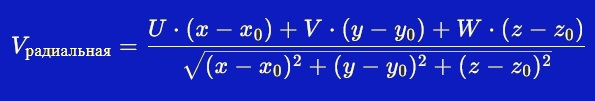
   - Результат сохраняется в массив `radial_velocity`.

#### Результаты:
Радиальная скорость представляет собой трехмерный массив, где каждый элемент соответствует проекции вектора скорости ветра на направление от заданной точки к точке сетки. Это позволяет анализировать распределение радиальной скорости в пространстве и использовать данные для дальнейших исследований или визуализации.

#### График
На графике представлен срез по 150 метрам по Z-оси по полученным данным 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interpn
import plotly.graph_objects as go
from functions import *

In [3]:
u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")

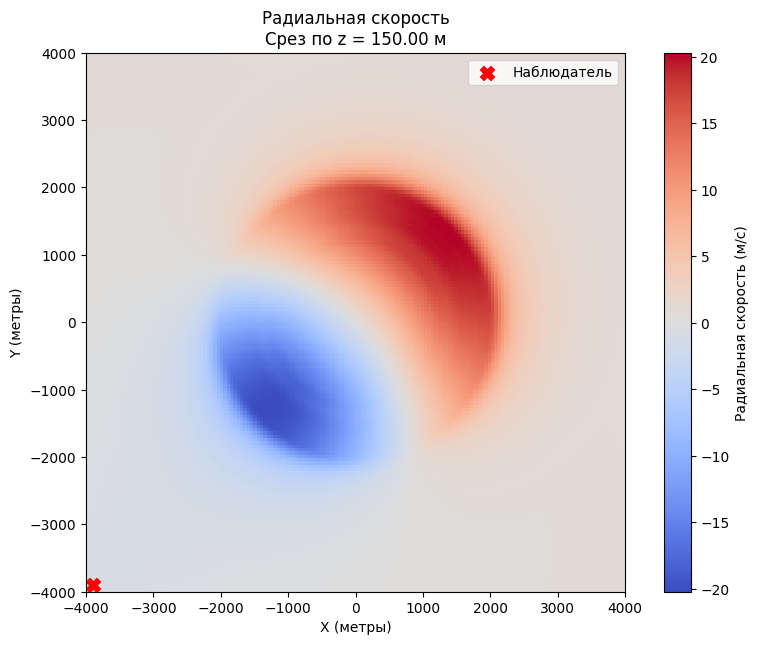

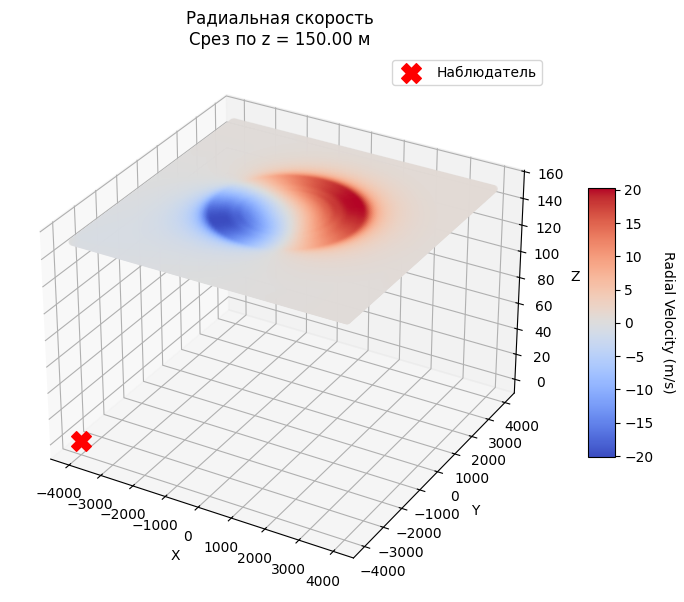

In [4]:
ix, iy, iz = u_data['dimensions']
xstart, ystart, zstart = u_data['origin_m']
dx, dy, dz = u_data['resolution_m']

#сетки координат
x = np.arange(xstart, xstart + ix * dx, dx)
y = np.arange(ystart, ystart + iy * dy, dy)
z = np.arange(zstart, zstart + iz * dz, dz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Заданная точка
x0, y0, z0 = -4000, -4000, 0  

# Вычисление разностей координат
delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0

distance = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)

distance[distance == 0] = 1e-10

# Расчет радиальной скорости
U = u_data['data']
V = v_data['data']
W = w_data['data']
radial_velocity = (U * delta_x + V * delta_y + W * delta_z) / distance



z_slice = 3

# print("Размерность поля радиальных скоростей:", radial_velocity.shape)


plt.figure(figsize=(10, 7))
plt.imshow(
    radial_velocity[:, :, z_slice],
    cmap='coolwarm',
    origin='lower',
    extent=[x.min(), x.max(), y.min(), y.max()]
)
plt.colorbar(label='Радиальная скорость (м/с)')
plt.title(f'Радиальная скорость\nСрез по z = {z_slice * dz + zstart:.2f} м')

plt.scatter(-3900, -3900, color='red', marker='X', s=100, label='Наблюдатель') 
plt.legend()

plt.xlabel('X (метры)')
plt.ylabel('Y (метры)')
plt.show()

# --- 3D-график ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X[:, :, z_slice].flatten(),
    Y[:, :, z_slice].flatten(),
    Z[:, :, z_slice].flatten(),
    c=radial_velocity[:, :, z_slice].flatten(),
    cmap='coolwarm'
)

ax.scatter(x0, y0, z0, color='red', marker='X', s=200, label='Наблюдатель') 

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Radial Velocity (m/s)', rotation=270, labelpad=15)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title(f'Радиальная скорость\nСрез по z = {z_slice * dz + zstart:.2f} м')
plt.legend()

plt.show()

### Описание расчетов проведения линии через трехмерный массив поля радиальных скоростей

В этом разделе описывается процесс проведения линии через трехмерный массив поля радиальных скоростей и извлечения значений радиальной скорости вдоль этой линии. Процесс включает несколько ключевых шагов: конвертацию углов в направляющий вектор, вычисление параметрического уравнения прямой, нахождение точек пересечения прямой с границами матрицы и трилинейную интерполяцию значений.

#### Основные шаги:

1. **Конвертация углов в направляющий вектор:**
   - Функция `spherical_to_cartesian` преобразует азимут и угол возвышения (в градусах) в направляющий вектор в декартовых координатах.
   - Азимут и угол возвышения задаются в градусах, после чего преобразуются в радианы для вычисления компонентов вектора.

2. **Параметрическое уравнение прямой:**
   - Функция `line_parametric` вычисляет координаты точек на прямой, проходящей через заданную начальную точку `origin` в направлении вектора `direction`.
   - Параметр `t` используется для определения положения точек вдоль прямой.

3. **Нахождение точек пересечения прямой с границами матрицы:**
   - Функция `find_intersection` определяет точки входа и выхода прямой в пределах трехмерной матрицы.
   - Для каждой оси вычисляются значения параметра `t`, соответствующие пересечению прямой с границами матрицы.
   - Минимальное и максимальное значения `t` определяют начальную и конечную точки пересечения прямой с матрицей.

4. **Трилинейная интерполяция:**
   - Функция `trilinear_interpolation` выполняет трилинейную интерполяцию значений внутри трехмерной матрицы.
   - Для заданной точки `(x, y, z)` вычисляются индексы ближайших узлов матрицы и коэффициенты интерполяции.
   - Значения в узлах матрицы интерполируются для получения значения в заданной точке.

5. **Расчет радиальной скорости и проведение линии:**
   - Задается начальная точка наблюдателя `x0, y0, z0` и параметры линии (азимут и угол возвышения) В данном случае задана точка `-4000, -4000, 0`, азимут и угол возвышения заданы `45, 0` соответственно, количество точек установлено `20`.
   - Вычисляется направляющий вектор линии и определяются точки пересечения прямой с границами матрицы.
   - Вдоль линии вычисляются координаты точек и извлекаются значения радиальной скорости с использованием трилинейной интерполяции.


#### Результаты:
В результате выполнения данного кода получается набор точек вдоль заданной линии и соответствующие значения радиальной скорости в этих точках. Этот процесс позволяет анализировать радиальную скорость вдоль заданной траектории.

#### Графики
На графиках представленны значения в м/с в полученных точках по удаленности в метрах от изначальной заданной точки.

In [5]:

def spherical_to_cartesian(azimuth_deg, elevation_deg):
    """Конвертируем углы в направляющий вектор"""
    azimuth = np.radians(azimuth_deg)
    elevation = np.radians(elevation_deg)
    x = np.cos(elevation) * np.cos(azimuth)
    y = np.cos(elevation) * np.sin(azimuth)
    z = np.sin(elevation)
    return np.array([x, y, z])

def line_parametric(t, origin, direction):
    """Параметрическое уравнение прямой"""
    return origin + direction * t

def find_intersection(matrix_shape, origin, direction):
    """Находим точки пересечения прямой с границами матрицы"""
    def get_t(axis, boundary):
        return (boundary - origin[axis]) / direction[axis] if direction[axis] != 0 else np.nan
    
    min_bounds = np.array([0, 0, 0])
    max_bounds = np.array(matrix_shape) - 1e-6  #  краевые эффекты
    
    t_enter = []
    t_exit = []
    
    for i in range(3):
        t1 = get_t(i, min_bounds[i])
        t2 = get_t(i, max_bounds[i])
        t_enter.append(min(t1, t2))
        t_exit.append(max(t1, t2))
    
    t_start = max(0, *[t for t in t_enter if not np.isnan(t)])
    t_end = min(*[t for t in t_exit if not np.isnan(t)])
    
    return t_start, t_end

def trilinear_interpolation(matrix, x, y, z):
    """Трилинейная интерполяция"""
    x0, y0, z0 = np.floor([x, y, z]).astype(int)
    x1, y1, z1 = x0 + 1, y0 + 1, z0 + 1
    
    # обработка выхода за границы
    x0, x1 = np.clip([x0, x1], 0, matrix.shape[0]-1)
    y0, y1 = np.clip([y0, y1], 0, matrix.shape[1]-1)
    z0, z1 = np.clip([z0, z1], 0, matrix.shape[2]-1)
    
    xd = (x - x0) / (x1 - x0) if (x1 - x0) != 0 else 0
    yd = (y - y0) / (y1 - y0) if (y1 - y0) != 0 else 0
    zd = (z - z0) / (z1 - z0) if (z1 - z0) != 0 else 0

    c00 = matrix[x0, y0, z0] * (1 - xd) + matrix[x1, y0, z0] * xd
    c01 = matrix[x0, y0, z1] * (1 - xd) + matrix[x1, y0, z1] * xd
    c10 = matrix[x0, y1, z0] * (1 - xd) + matrix[x1, y1, z0] * xd
    c11 = matrix[x0, y1, z1] * (1 - xd) + matrix[x1, y1, z1] * xd

    c0 = c00 * (1 - yd) + c10 * yd
    c1 = c01 * (1 - yd) + c11 * yd

    return c0 * (1 - zd) + c1 * zd


In [6]:
def plot_line_results(V_radial, z_slice, x, y, points, values, distance, observer_position):
    """
    Визуализация результатов: радиальная скорость и профиль скорости.
    
    Args:
        V_radial (np.ndarray): 3D массив радиальных скоростей.
        z_slice (int): Индекс среза по оси Z.
        x (np.ndarray): Координаты по оси X.
        y (np.ndarray): Координаты по оси Y.
        points (np.ndarray): Точки на линии.
        values (list): Значения радиальной скорости в точках.
        distance (np.ndarray): Расстояния между точками.
        observer_position (tuple): Позиция наблюдателя (x0, y0).
    """
    import matplotlib.pyplot as plt

    # Срез радиальной скорости
    radial_slice = V_radial[:, :, z_slice]

    plt.figure(figsize=(14, 6))

    # Подграфик 1: Вид сверху
    plt.subplot(1, 2, 1)
    plt.imshow(
        radial_slice.T,
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin='lower',
        cmap='coolwarm',
        alpha=0.6
    )
    plt.colorbar(label='Радиальная скорость (м/с)')

    # Точки линии
    plt.scatter(
        points[:, 0], points[:, 1],
        c=values, cmap='coolwarm', s=50, edgecolor='w',
        label='Точки линии'
    )
    plt.plot(points[:, 0], points[:, 1], color='blue', linestyle='-', linewidth=2, label='Линия')
    
    # Наблюдатель
    plt.scatter(
        observer_position[0]+100, observer_position[1]+100,
        color='red', marker='X', s=100, label='Наблюдатель'
    )

    # Подписи значений у точек
    for i in range(len(points)):
        plt.text(
            points[i, 0], points[i, 1],
            f'{values[i]:.1f} м/с',
            fontsize=8,
            ha='right',
            va='bottom',
            color='black',
            bbox=dict(boxstyle='round,pad=0.2',
                      edgecolor='white',
                      facecolor='white',
                      alpha=0.7)
        )

    plt.xlabel('X (м)')
    plt.ylabel('Y (м)')
    plt.title('Вид сверху (z=150 м)')
    plt.legend()
    plt.grid(True)

    # Подграфик 2: Профиль скорости
    plt.subplot(1, 2, 2)
    plt.plot(distance, values, marker='o', linestyle='-', color='b')
    plt.xlabel('Расстояние вдоль линии (м)')
    plt.ylabel('Радиальная скорость (м/с)')
    plt.title('Профиль радиальной скорости')
    plt.grid(True)

    # Подписи значений у профиля
    for i in range(len(distance)):
        plt.text(
            distance[i], values[i],
            f'{values[i]:.1f} м/с',
            fontsize=8,
            ha='right',
            va='bottom',
            color='black',
            bbox=dict(boxstyle='round,pad=0.2',
                      edgecolor='white',
                      facecolor='white',
                      alpha=0.7)
        )

    plt.tight_layout()
    plt.show()

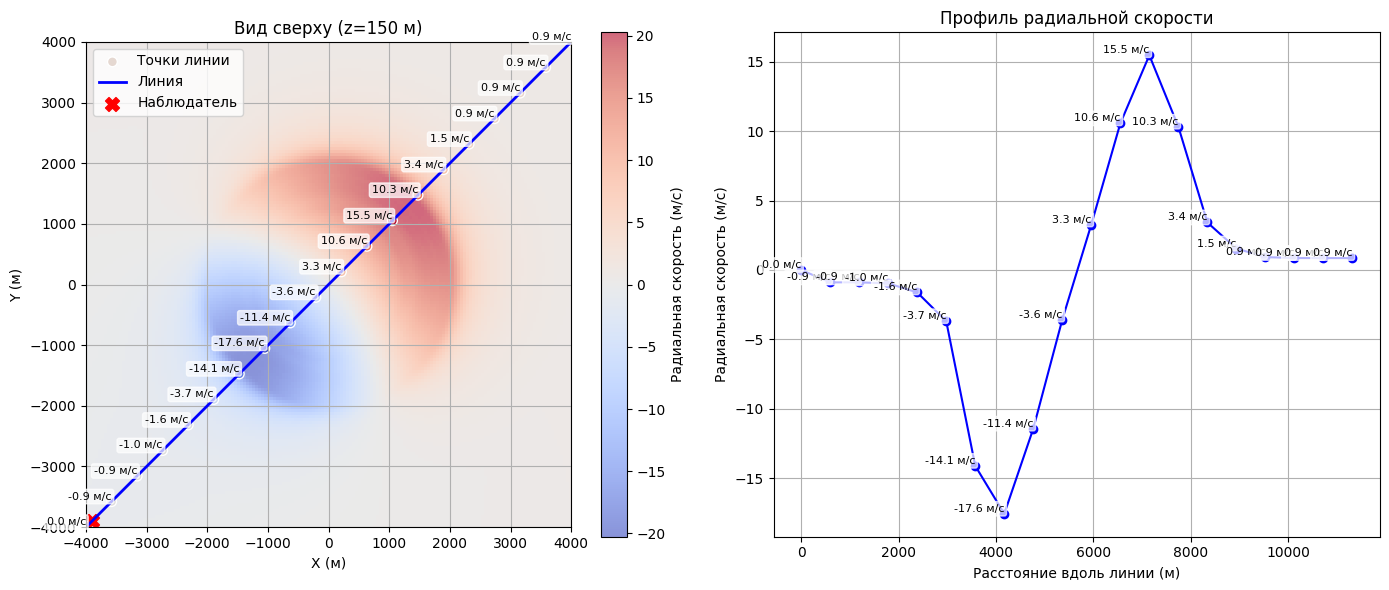

In [14]:
u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")

origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions']       # Размеры сетки

# Создание сетки в реальных координатах
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 = -4000, -4000, 150 # Точка наблюдателя
# Параметры линии
azimuth_deg = 45# Горизонтальный угол
elevation_deg = 1  # Вертикальный угол
num_points = 20    # Количество точек



delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)

# в реальных координатах
origin_line = np.array([x0, y0, z0])

# пересечения с матрицей
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])

matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  

values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))

# print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  # Начальное расстояние 0 метров

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #

distance = np.array(distance)

z_slice = np.argmin(np.abs(z - 150))  # Индекс слоя z=150
plot_line_results(V_radial, z_slice, x, y, points, values, distance, observer_position=(x0, y0))

<h1><center>График — 1. Изначальная линия проходящая по диагонали через всю матрицу</center></h1>

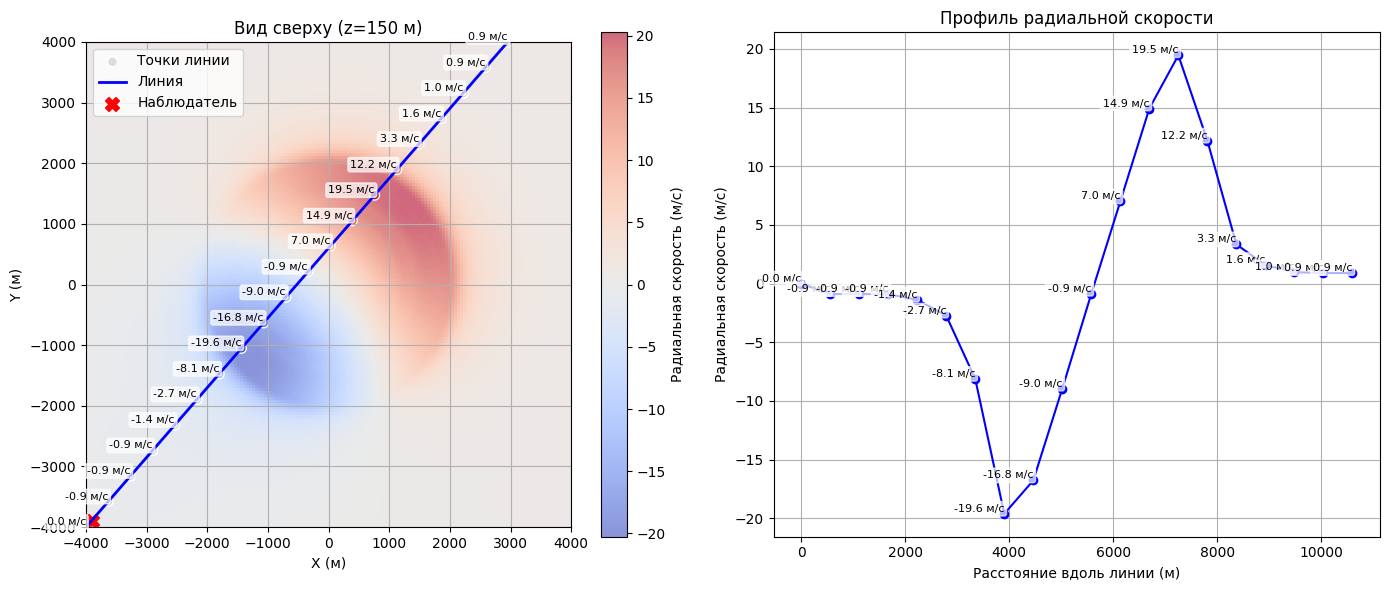

In [8]:
origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions'] 
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 = -4000, -4000, 150  # Точка наблюдателя
# Параметры линии
azimuth_deg = 49    # Горизонтальный угол
elevation_deg = 0  # Вертикальный угол
num_points = 20    # Количество точек
delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)
origin_line = np.array([x0, y0, z0])
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])
matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  
values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))
# print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #
distance = np.array(distance)
plot_line_results(V_radial, z_slice, x, y, points, values, distance, observer_position=(x0, y0))

<h1><center>График — 2. Линия с измененным горизонтальным углом на +4</center></h1>

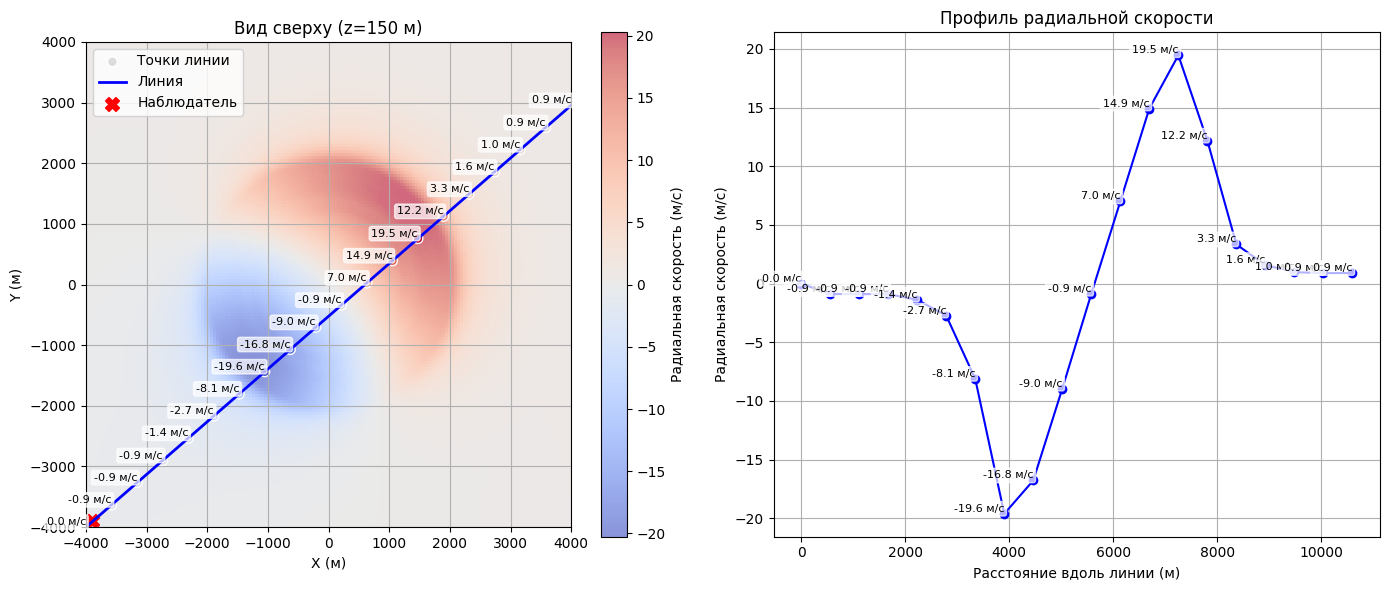

In [9]:
origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions'] 
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 = -4000, -4000, 150  # Точка наблюдателя
# Параметры линии
azimuth_deg = 41    # Горизонтальный угол
elevation_deg = 0  # Вертикальный угол
num_points = 20    # Количество точек
delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)
origin_line = np.array([x0, y0, z0])
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])
matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  
values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))
# print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #
distance = np.array(distance)
plot_line_results(V_radial, z_slice, x, y, points, values, distance, observer_position=(x0, y0))

<h1><center>График — 3. Линия с измененным горизонтальным углом на -4</center></h1>

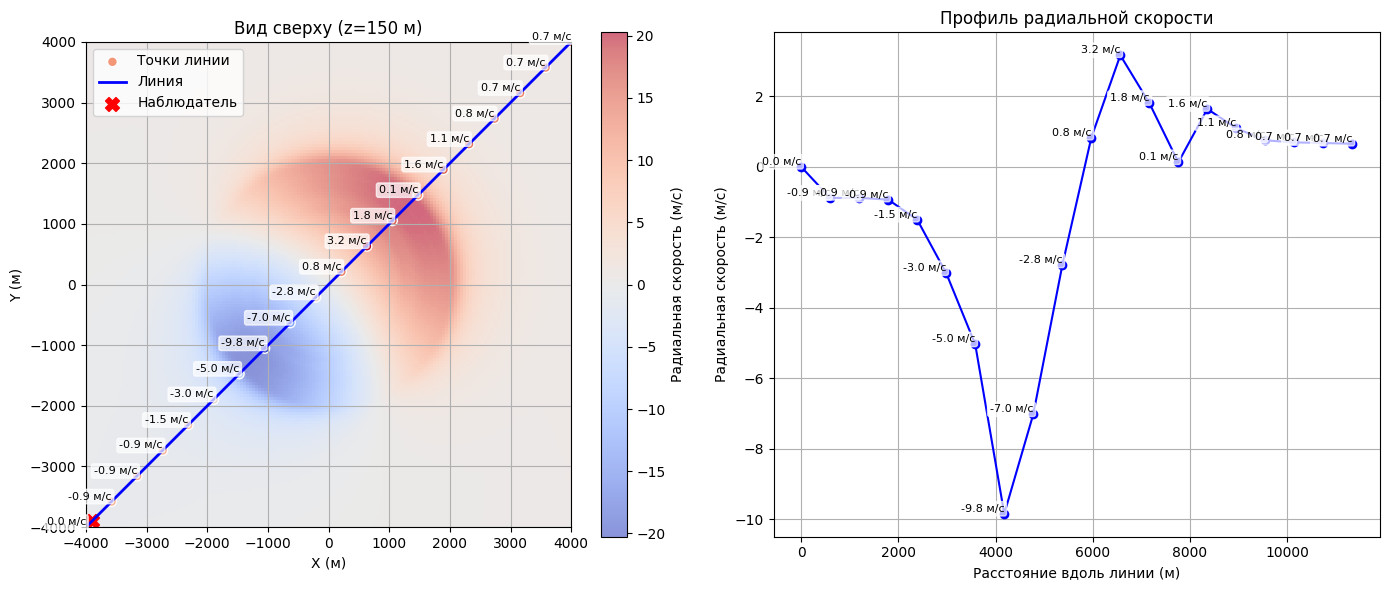

In [10]:
origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions'] 
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 = -4000, -4000, 150  # Точка наблюдателя
# Параметры линии
azimuth_deg = 45    # Горизонтальный угол
elevation_deg = 4  # Вертикальный угол
num_points = 20    # Количество точек
delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)
origin_line = np.array([x0, y0, z0])
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])
matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  
values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))
# print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #
distance = np.array(distance)
plot_line_results(V_radial, z_slice, x, y, points, values, distance, observer_position=(x0, y0))

<h1><center>График — 4. Линия с измененным вертикальным углом на +4</center></h1>

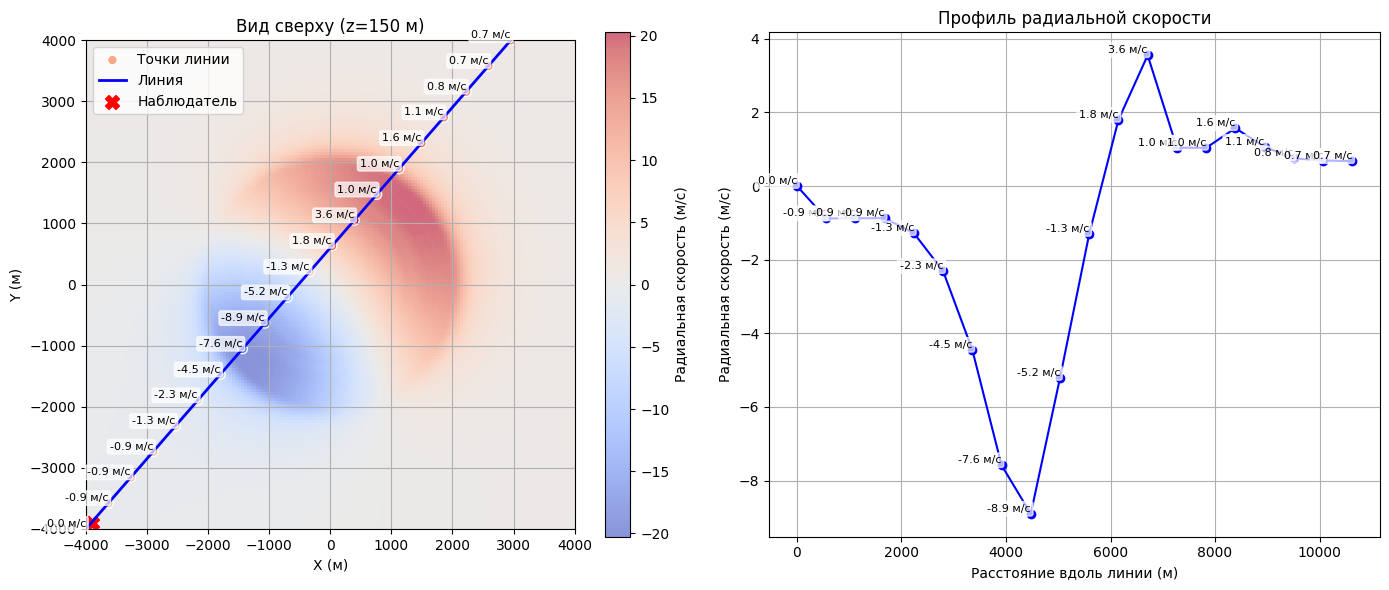

In [11]:
origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions'] 
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 = -4000, -4000, 150  # Точка наблюдателя
# Параметры линии
azimuth_deg = 49    # Горизонтальный угол
elevation_deg = 4  # Вертикальный угол
num_points = 20    # Количество точек
delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)
origin_line = np.array([x0, y0, z0])
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])
matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  
values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))
# print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #
distance = np.array(distance)
plot_line_results(V_radial, z_slice, x, y, points, values, distance, observer_position=(x0, y0))

<h1><center>График — 5. Линия с измененным вертикальным углом на +4 и горизонтальный угол на +4</center></h1>

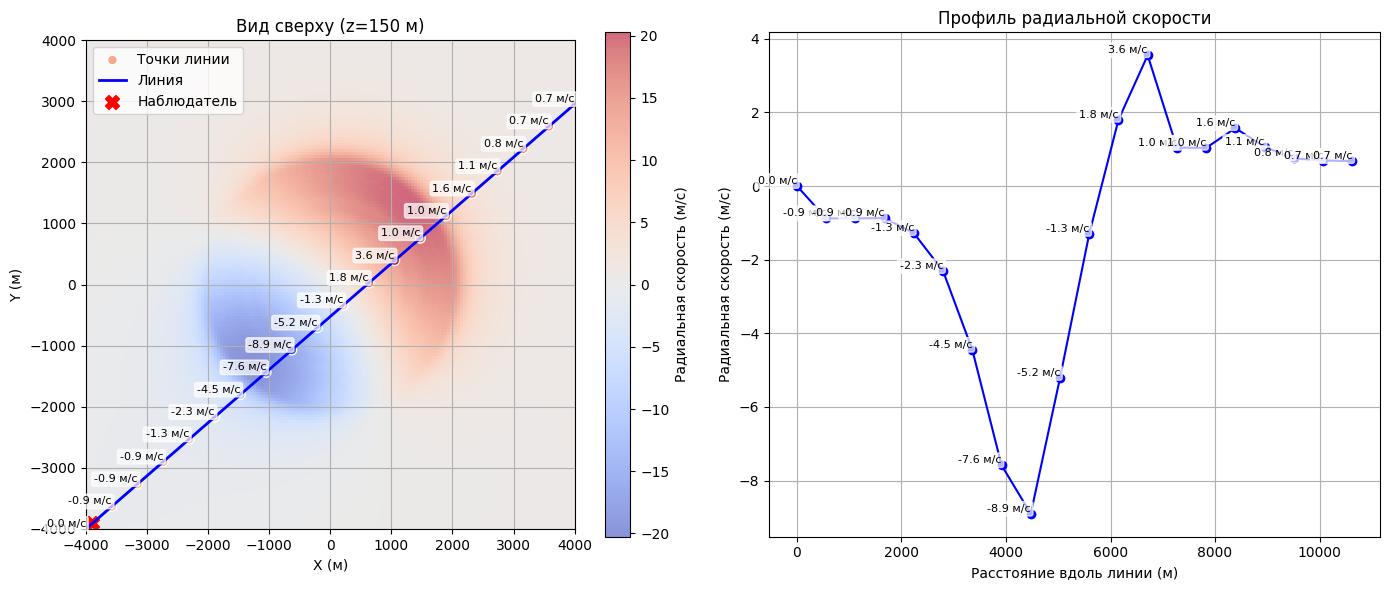

In [12]:
origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions'] 
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 = -4000, -4000, 150  # Точка наблюдателя
# Параметры линии
azimuth_deg = 41    # Горизонтальный угол
elevation_deg = 4  # Вертикальный угол
num_points = 20    # Количество точек
delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)
origin_line = np.array([x0, y0, z0])
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])
matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  
values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))
# print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #
distance = np.array(distance)
plot_line_results(V_radial, z_slice, x, y, points, values, distance, observer_position=(x0, y0))

<h1><center>График — 6. Линия с измененным вертикальным углом на +4 и горизонтальный угол на -4</center></h1>